# Cálculo de VaR con TimeGAN y Simulación de Monte Carlo

Este notebook implementa un flujo completo para:
1. Cargar y preprocesar datos históricos de precios de acciones
2. Entrenar un modelo TimeGAN
3. Generar datos sintéticos futuros
4. Calcular el VaR mediante simulación de Monte Carlo

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import tensorflow as tf

# Añadir el directorio raíz al path
sys.path.append(os.path.abspath('..'))

# Importar módulos del proyecto
from src.data.loader import load_stock_data, check_data_quality
from src.data.transform import calculate_returns, add_features, normalize_data, inverse_normalize, build_multi_asset_portfolio
from src.data.windowing import create_windows, recreate_time_series
from src.models.timegan import timegan_init, timegan_train, timegan_export_generator, generator_gen, generator_save, generator_load
from src.models.var_model import monte_carlo_var, parametric_var, historical_var
from src.utils.evaluation import prepare_data_for_evaluation, calculate_kl_divergence, discriminative_score, predictive_score, visualize_tsne
from src.utils.visualization import plot_portfolio_value, plot_stock_prices, plot_returns_distribution, plot_acf_comparison, plot_var_histogram, plot_multiple_var_methods, plot_synthetic_returns

# Configurar semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

2025-05-03 00:20:46.837999: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-03 00:20:48.092945: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 1. Descargar y Preprocesar Datos

En la tupla `tickers` meta los tickers de los activos que quiere incluir en el portafolio y que se encuentren en yahoo finance y en la tupla `weights` meta los pesos que tienen en su portafolio. En este caso vamos a usar una estrategia naive muy basica para exponernos al mercado estadounidense y europeo.

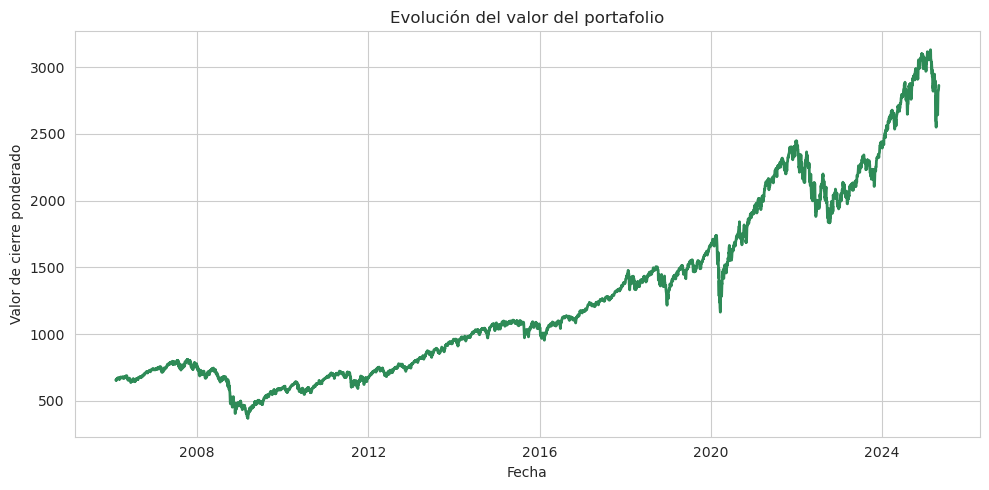

In [2]:
# Definicion del portafolio
#build_multi_asset_portfolio(("^GSPC", "AGG", "DBC", "GLD"), (0.5, 0.3, 0.1, 0.1)).to_csv('../data/input/portafolio.csv')
h = pd.read_csv('../data/input/portafolio.csv', parse_dates=['Date'])
h.drop(columns=['Unnamed: 0'], inplace=True)

# Visualizar el valor del portafolio en el tiempo
plot_portfolio_value(h)

In [3]:
# Calcular rendimientos y añadir características
df = calculate_returns(h, method='log')
#df.head()

In [4]:
# Normalizar los datos para el entrenamiento del modelo
features_to_normalize = [col for col in df.columns if col != 'Date']
df_norm, norm_params = normalize_data(df, features=features_to_normalize, method='minmax')
df_norm.set_index('Date', inplace=True)

# Exportar los datos normalizados
df_norm.to_csv('../data/processed/portafolio_normalizado.csv', index=False)

# Cargar los datos normalizados
#df_norm = pd.read_csv('../data/processed/portafolio_normalizado.csv', parse_dates=['Date'])

In [5]:
# Crear ventanas temporales para el entrenamiento
window_size = 250  # un año de datos históricos
stride = 1       # Avanzar de 1 en 1 día para crear ventanas

# Seleccionar características para el modelo
selected_features = ['Returns']
windows = create_windows(df_norm[selected_features], window_size=window_size, stride=stride)

print(f"Forma de las ventanas de entrenamiento: {windows.shape}")

Forma de las ventanas de entrenamiento: (4590, 250, 1)


## 2. Entrenar el Modelo TimeGAN

In [6]:
# Definir parámetros del modelo
time_series_len = window_size
features = len(selected_features)
rnn_units = 32   # Unidades en cada capa GRU
rnn_layers = 4   # Número de capas GRU

# Inicializar el modelo TimeGAN
#timegan_tuple = timegan_init(time_series_len, features, rnn_units, rnn_layers)

# Parámetros de entrenamiento
epochs = 3000      # Reducido para demostración, usar 1000-2000 para resultados óptimos
batch_size = 64
learning_rate = 0.001

# Entrenar el modelo (esto puede tomar tiempo)
#trained_timegan = timegan_train(windows, timegan_tuple, epochs, batch_size, learning_rate)

# Exportar el generador
#syn_generator = timegan_export_generator(trained_timegan)

# Guardar el modelo entrenado
#os.makedirs('../models', exist_ok=True)
#generator_save(syn_generator, '../models/timegan_stock_model.weights.h5')

## 3. Generar Datos Sintéticos y Evaluar

In [7]:

# Cargar el modelo guardado (opcional, si se quiere saltar el entrenamiento)
syn_generator = generator_load('../models/timegan_stock_model.weights.h5', time_series_len, features, rnn_units, rnn_layers)

# Generar datos sintéticos
n_simulations = 100000  # Número de trayectorias sintéticas
synthetic_windows = generator_gen(syn_generator, generate_cnt=n_simulations)
synthetic_windows[0].shape

2025-05-03 00:20:50.112074: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-03 00:20:50.521301: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-03 00:20:50.521379: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-03 00:20:50.526783: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-03 00:20:50.526865: I external/local_xla/xla/stream_executor

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 381s 122ms/step


(250, 1)

In [8]:
# Preparar los datos para evaluación
real_windows, synthetic_windows = prepare_data_for_evaluation(
    df_norm['Returns'].to_numpy(), 
    synthetic_windows,
    window_size=250,
    stride=50  # Puedes usar superposición para aumentar las muestras reales
)

# Evaluar la calidad de los datos sintéticos
kl_div = calculate_kl_divergence(real_windows, synthetic_windows)
disc_score = discriminative_score(real_windows, synthetic_windows)
pred_score = predictive_score(real_windows, synthetic_windows)

print(f"Divergencia KL: {kl_div:.4f}")
print(f"Discriminative Score: {disc_score:.4f}")
print(f"Predictive Score (MSE): {pred_score:.4f}")

Divergencia KL: 178.8790
Discriminative Score: 0.9998
Predictive Score (MSE): 2.8084
